In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set()

# Paleta del curso
AZUL = "#007aff"
MAGENTA = "#ff48fd"
VERDE = "#44c57f"
NARANJA = "#ffa600"
CELESTE = "#8ecae6"
GRIS = "#555555"

# Calibración con pocos datos
**Aprendizaje de Máquina - CEIA - FIUBA**

En la notebook `1 - Calibracion de modelos` trabajamos con 30.000 observaciones. Todo funcionó de manera limpia: las
curvas eran suaves, las métricas se movían de forma clara y las conclusiones eran contundentes.

Acá vamos a hacer lo mismo con **768 observaciones**, que es la situación mucho más habitual en la práctica. Y vamos
a descubrir que **la mayoría de esas conclusiones dejan de poder sacarse**.

El objetivo de esta notebook no es aprender un método nuevo, sino aprender a **desconfiar de lo que la curva de
calibración muestra cuando hay pocos datos**.

## Los datos

Usamos el dataset **Pima Indians Diabetes**, que ya conocemos: apareció en las notebooks de las clases 2, 3, 4 y 5.

Son datos clínicos de 768 mujeres de la comunidad Pima, y el objetivo es predecir el diagnóstico de diabetes a
partir de medidas diagnósticas.

> Si querés repasar las variables, los ceros enmascarados y las correlaciones, está la notebook
> **`EDA - Pima Diabetes`** de la clase 2.

In [2]:
df = pd.read_csv("data/pima_diabetes.csv")
df.head()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.drop(columns="diabetes")
y = df["diabetes"]

tasa_base = y.mean()
piso = tasa_base * (1 - tasa_base)

print(f"Observaciones: {len(y)}, features: {X.shape[1]}")
print(f"Tasa base de diabetes: {tasa_base:.4f}  ({tasa_base:.2%})")
print(f"Piso del Brier Score, ȳ(1-ȳ): {piso:.4f}")

Observaciones: 768, features: 8
Tasa base de diabetes: 0.3490  (34.90%)
Piso del Brier Score, ȳ(1-ȳ): 0.2272


Un $34.9\%$ de casos positivos: bastante más balanceado que el dataset de crédito.

Separamos en entrenamiento y testeo con la misma proporción que antes.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

print(f"Train: {len(y_train)} | Test: {len(y_test)}")

Train: 537 | Test: 231


Y acá aparece el primer problema, antes de entrenar nada.

**El conjunto de testeo tiene 231 observaciones.** Si dibujamos una curva de calibración con 10 bins, cada bin va a
tener en promedio **23 observaciones**. Con 23 observaciones, la frecuencia observada de positivos tiene un error
estándar de alrededor de $\pm 0.10$.

Es decir: **cada punto de la curva va a tener una barra de error de diez puntos porcentuales**, aunque no la
dibujemos. Tengamos eso presente en todo lo que sigue.

## Dos modelos

Entrenamos los dos modelos que en el dataset grande dieron los extremos: el Random Forest, que estaba bien
calibrado, y Naive Bayes, que era un desastre.

In [5]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
gnb = make_pipeline(StandardScaler(), GaussianNB())

rf.fit(X_train, y_train)
gnb.fit(X_train, y_train)

probs = {
    "Random Forest": rf.predict_proba(X_test)[:, 1],
    "Naive Bayes": gnb.predict_proba(X_test)[:, 1],
}

In [6]:
def expected_calibration_error(y_true, probs, n_bins=10):
    """Distancia media a la diagonal, ponderada por el tamaño de cada bin."""
    y_true = np.asarray(y_true)
    bordes = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(probs, bordes[1:-1]), 0, n_bins - 1)

    ece = 0.0
    for b in range(n_bins):
        mask = idx == b
        if not mask.any():
            continue
        ece += mask.sum() / len(probs) * abs(y_true[mask].mean() - probs[mask].mean())
    return ece


def resumen(y_true, probs_dict):
    return pd.DataFrame({
        nombre: {
            "AUC": roc_auc_score(y_true, p),
            "Accuracy": accuracy_score(y_true, p >= 0.5),  # noqa: PLR2004
            "Brier": brier_score_loss(y_true, p),
            "ECE": expected_calibration_error(y_true, p),
        }
        for nombre, p in probs_dict.items()
    }).T


resumen(y_test, probs).round(4)

,AUC,Accuracy,Brier,ECE
Random Forest,0.8389,0.8009,0.1543,0.0747
Naive Bayes,0.8267,0.7749,0.1749,0.1122


Los dos discriminan parecido y los dos están por debajo del piso de $0.2272$, así que ambos aportan algo. Naive
Bayes tiene peor ECE, igual que en el dataset grande.

Hasta acá, todo parece funcionar como antes. Ahora empecemos a mirar con desconfianza.

## Problema 1: la respuesta depende de cuántos bins elijamos

El ECE y la curva de calibración se construyen agrupando las predicciones en bins. Esa elección es nuestra, y **no
es inocente**. Calculemos el ECE del mismo modelo, con las mismas predicciones, variando solo el número de bins.

In [7]:
tabla_bins = pd.DataFrame({
    "obs. por bin (prom.)": [len(y_test) // n for n in [5, 10, 15, 20]],
    "ECE Random Forest": [expected_calibration_error(y_test, probs["Random Forest"], n)
                          for n in [5, 10, 15, 20]],
    "ECE Naive Bayes": [expected_calibration_error(y_test, probs["Naive Bayes"], n)
                        for n in [5, 10, 15, 20]],
}, index=pd.Index([5, 10, 15, 20], name="n_bins"))

tabla_bins.round(4)

,obs. por bin (prom.),ECE Random Forest,ECE Naive Bayes
n_bins,,,
5,46,0.0536,0.1081
10,23,0.0747,0.1122
15,15,0.0756,0.1173
20,11,0.0871,0.1262


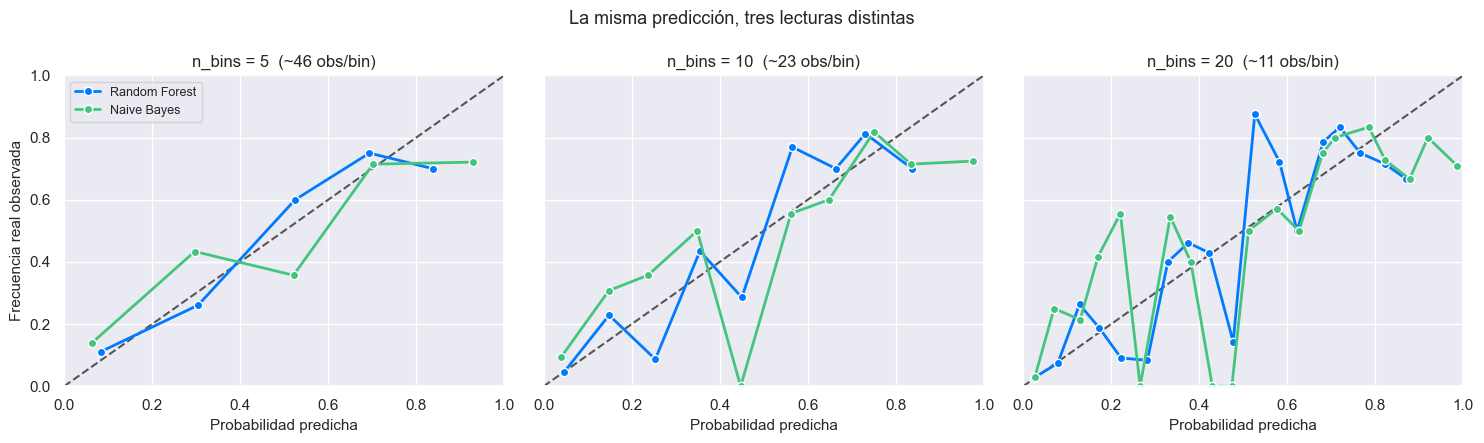

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, n_bins in zip(axes, [5, 10, 20]):
    ax.plot([0, 1], [0, 1], "--", lw=1.5, color=GRIS)
    for (nombre, p), color in zip(probs.items(), [AZUL, VERDE]):
        frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=n_bins)
        ax.plot(mean_pred, frac_pos, "o-", lw=2, markersize=6, color=color,
                markeredgecolor="white", markeredgewidth=1, label=nombre)
    ax.set_title(f"n_bins = {n_bins}  (~{len(y_test) // n_bins} obs/bin)", fontsize=12)
    ax.set_xlabel("Probabilidad predicha", fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Frecuencia real observada", fontsize=11)
axes[0].legend(fontsize=9, loc="upper left")
plt.suptitle("La misma predicción, tres lecturas distintas", fontsize=13)
plt.tight_layout()
plt.show()

Son **exactamente las mismas predicciones** en los tres paneles. Lo único que cambia es cómo las agrupamos.

Con 5 bins las curvas parecen razonables y suaves. Con 20 bins se vuelven un zigzag, y el ECE crece de forma
monótona, no porque el modelo empeore sino porque **cada bin tiene menos observaciones y la frecuencia observada se
vuelve más ruidosa**.

Esta es la razón por la que el ECE nunca debe reportarse sin decir con cuántos bins se calculó, y por la que no
tiene sentido comparar ECEs calculados con distinto binning.

## Problema 2: la respuesta depende de qué split nos tocó

El binning al menos es una decisión nuestra. El siguiente problema no lo es.

Repitamos exactamente el mismo experimento —mismo modelo, mismo código, mismos hiperparámetros— cambiando
únicamente la semilla del `train_test_split`.

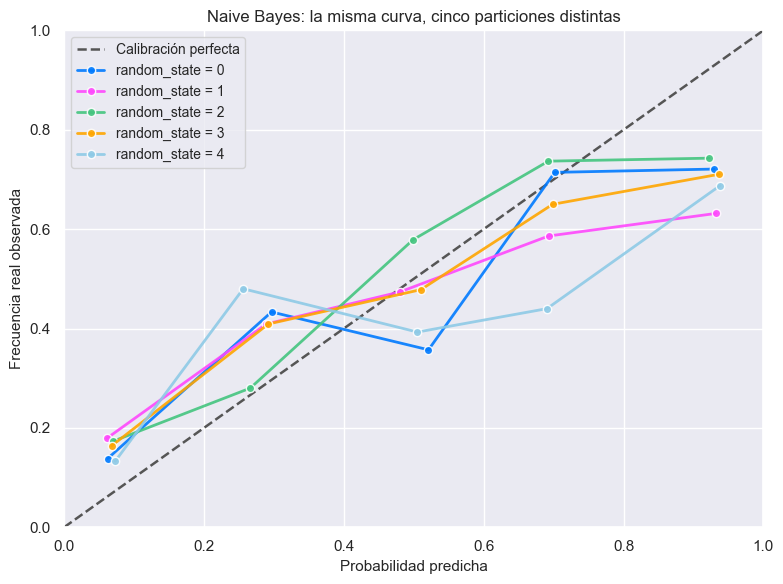

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "--", lw=1.8, color=GRIS, label="Calibración perfecta")

colores_seed = [AZUL, MAGENTA, VERDE, NARANJA, CELESTE]

for seed, color in zip(range(5), colores_seed):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    modelo = make_pipeline(StandardScaler(), GaussianNB()).fit(Xtr, ytr)
    p = modelo.predict_proba(Xte)[:, 1]

    frac_pos, mean_pred = calibration_curve(yte, p, n_bins=5)
    ax.plot(mean_pred, frac_pos, "o-", lw=2, markersize=6, color=color,
            markeredgecolor="white", markeredgewidth=1, alpha=0.9,
            label=f"random_state = {seed}")

ax.set_xlabel("Probabilidad predicha", fontsize=11)
ax.set_ylabel("Frecuencia real observada", fontsize=11)
ax.set_title("Naive Bayes: la misma curva, cinco particiones distintas", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

Es el mismo modelo sobre el mismo dataset. Y sin embargo, en el bin central —el de las predicciones cercanas a
$0.5$— la frecuencia real observada va de $0.36$ a $0.58$ según qué partición nos tocó.

**Veintidós puntos porcentuales de diferencia, producidos únicamente por el azar de la partición.**

Si hubiéramos corrido esta notebook una sola vez con `random_state=0`, habríamos concluido que el modelo sobreestima
en la zona media. Con `random_state=2` habríamos concluido lo contrario. Ninguna de las dos conclusiones sería
sólida.

## Cuantificar la incertidumbre: repetir el experimento

La forma de salir de este problema es la misma que ya conocemos de otras clases: **no confiar en una sola
partición**. Repetimos el experimento completo sobre 15 particiones distintas y miramos la dispersión.

In [10]:
def rf_nuevo():
    return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)


def gnb_nuevo():
    return make_pipeline(StandardScaler(), GaussianNB())


def calibrado(base, metodo):
    return CalibratedClassifierCV(base, method=metodo, cv=5)


def experimento(seed):
    """Entrena y calibra ambos modelos sobre una partición y devuelve las métricas."""
    x_tr, x_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)

    modelos = {
        "RF": rf_nuevo(),
        "RF + Platt": calibrado(rf_nuevo(), "sigmoid"),
        "RF + Isotónica": calibrado(rf_nuevo(), "isotonic"),
        "NB": gnb_nuevo(),
        "NB + Platt": calibrado(gnb_nuevo(), "sigmoid"),
        "NB + Isotónica": calibrado(gnb_nuevo(), "isotonic"),
    }

    filas = []
    for nombre, m in modelos.items():
        m.fit(x_tr, y_tr)
        p = m.predict_proba(x_te)[:, 1]
        filas.append({
            "modelo": nombre, "seed": seed,
            "Brier": brier_score_loss(y_te, p),
            "ECE": expected_calibration_error(y_te, p),
            "AUC": roc_auc_score(y_te, p),
        })
    return filas


resultados = pd.DataFrame([f for s in range(15) for f in experimento(s)])
resultados.head()

,modelo,seed,Brier,ECE,AUC
0,RF,0,0.154333,0.074675,0.838930
1,RF + Platt,0,0.152567,0.050740,0.845021
2,RF + Isotónica,0,0.150607,0.063083,0.844938
3,NB,0,0.174896,0.112238,0.826749
4,NB + Platt,0,0.166129,0.076078,0.825926


In [11]:
resumen_rep = resultados.groupby("modelo")[["Brier", "ECE", "AUC"]].agg(["mean", "std"])
resumen_rep.reindex(["RF", "RF + Platt", "RF + Isotónica",
                     "NB", "NB + Platt", "NB + Isotónica"]).round(4)

Brier             ECE             AUC        
                  mean     std    mean     std    mean     std
modelo                                                        
RF              0.1594  0.0117  0.0567  0.0139  0.8296  0.0251
RF + Platt      0.1596  0.0123  0.0661  0.0199  0.8324  0.0260
RF + Isotónica  0.1614  0.0143  0.0688  0.0210  0.8291  0.0255
NB              0.1807  0.0150  0.1185  0.0152  0.8148  0.0234
NB + Platt      0.1712  0.0097  0.0679  0.0189  0.8156  0.0229
NB + Isotónica  0.1694  0.0111  0.0725  0.0179  0.8153  0.0238

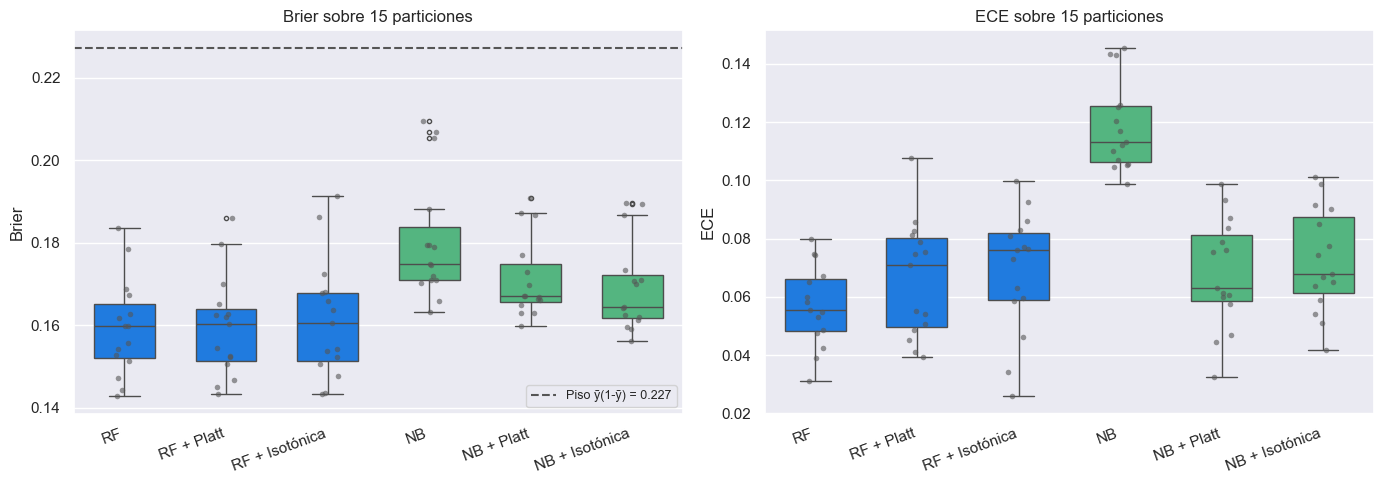

In [12]:
orden = ["RF", "RF + Platt", "RF + Isotónica", "NB", "NB + Platt", "NB + Isotónica"]
paleta = [AZUL, AZUL, AZUL, VERDE, VERDE, VERDE]   # azul = RF, verde = NB

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrica in zip(axes, ["Brier", "ECE"]):
    sns.boxplot(data=resultados, x="modelo", y=metrica, order=orden,
                hue="modelo", hue_order=orden, palette=paleta, legend=False,
                ax=ax, width=0.6, fliersize=3)
    sns.stripplot(data=resultados, x="modelo", y=metrica, order=orden,
                  color=GRIS, size=4, alpha=0.6, ax=ax)
    ax.set_title(f"{metrica} sobre 15 particiones", fontsize=12)
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

axes[0].axhline(piso, color="#555555", linestyle="--", lw=1.5,
                label=f"Piso ȳ(1-ȳ) = {piso:.3f}")
axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

Ahora sí podemos leer algo. Las cajas se superponen mucho, y esa superposición **es el resultado**: nos dice qué
diferencias son reales y cuáles son ruido.

## Qué se puede afirmar y qué no

Contemos, sobre las 15 particiones, en cuántas cada comparación da a favor.

In [13]:
pivot = resultados.pivot(index="seed", columns="modelo", values="Brier")
pivot_ece = resultados.pivot(index="seed", columns="modelo", values="ECE")

comparaciones = {
    "Calibrar mejora a Naive Bayes (Brier)": pivot["NB + Platt"] < pivot["NB"],
    "Calibrar mejora a Naive Bayes (ECE)": pivot_ece["NB + Platt"] < pivot_ece["NB"],
    "Calibrar mejora al Random Forest (Brier)": pivot["RF + Platt"] < pivot["RF"],
    "Platt le gana a Isotónica en RF": pivot["RF + Platt"] < pivot["RF + Isotónica"],
    "Platt le gana a Isotónica en NB": pivot["NB + Platt"] < pivot["NB + Isotónica"],
}

pd.DataFrame({
    "veces a favor": {k: f"{v.sum()} / 15" for k, v in comparaciones.items()},
    "proporción": {k: v.mean() for k, v in comparaciones.items()},
}).round(2)

,veces a favor,proporción
Calibrar mejora a Naive Bayes (Brier),15 / 15,1.00
Calibrar mejora a Naive Bayes (ECE),15 / 15,1.00
Calibrar mejora al Random Forest (Brier),6 / 15,0.40
Platt le gana a Isotónica en RF,11 / 15,0.73
Platt le gana a Isotónica en NB,4 / 15,0.27


Tres lecturas muy distintas:

**1. Calibrar Naive Bayes funciona: 15 de 15.** No hay ambigüedad. Cuando la descalibración es grande —el ECE de
Naive Bayes ronda $0.12$— calibrar ayuda incluso con 537 observaciones de entrenamiento. La señal es mucho más
grande que el ruido.

**2. Calibrar el Random Forest es tirar una moneda: 6 de 15.** Y tiene sentido: el Random Forest ya venía
razonablemente calibrado (ECE $\approx 0.057$), así que no hay casi nada que corregir. Lo único que agregamos es la
varianza de estimar dos parámetros más con pocos datos. **Calibrar un modelo que ya está calibrado lo empeora.**

**3. Platt versus isotónica: no se puede responder con estos datos.** Da 11 de 15 en un modelo y 4 de 15 en el otro.
Con 15 particiones, esos números son perfectamente compatibles con que no haya ninguna diferencia real.

Eso no invalida la regla teórica de que la isotónica necesita más datos —de hecho su ECE es en promedio algo peor y
más variable—, pero sí muestra que **en un caso concreto con pocos datos no vamos a poder verificarla midiendo**.

### La comparación con el dataset grande

Pongamos los dos casos lado a lado.

| | UCI Credit Card | Pima Diabetes |
|---|---|---|
| Observaciones de entrenamiento | 21.000 | 537 |
| Observaciones de testeo | 9.000 | 231 |
| Observaciones por bin (10 bins) | ~900 | ~23 |
| ¿La curva es legible? | Sí, suave | No, ruidosa |
| ¿Se distinguen Platt e isotónica? | Sí (ECE 0.019 vs 0.014) | No |
| ¿Alcanza con una partición? | Sí | **No** |

La diferencia no es que un dataset sea "mejor" que el otro. Es que con 231 observaciones de testeo, **el error de
medición es del mismo orden que el efecto que queremos medir**.

## Cierre: reglas prácticas para datasets chicos

1. **Nunca saques conclusiones de calibración de una sola partición.** Repetí el experimento con varias semillas y
   mirá la dispersión, igual que hacés con cualquier otra métrica.
2. **Usá pocos bins.** Con 231 observaciones de testeo, 5 bins es razonable y 20 es puro ruido. Como referencia
   práctica, apuntá a un mínimo de 30-50 observaciones por bin.
3. **Reportá siempre el `n_bins` junto al ECE.** Sin ese dato el número no es interpretable ni comparable.
4. **Calibrá solo si hay algo que corregir.** Medí primero: si el modelo ya está razonablemente calibrado, calibrarlo
   agrega varianza sin beneficio.
5. **Ante la duda entre Platt e isotónica, elegí Platt.** No porque puedas demostrar que gana en tu caso, sino
   porque con dos parámetros el riesgo de sobreajustar es mucho menor que con una función escalonada libre.
6. **Usá validación cruzada, no hold-out.** Con estos volúmenes, separar un conjunto de calibración te deja sin
   datos suficientes ni para entrenar ni para calibrar.
